# nb02 — reconciliation harness (Session 2B, Gate 2)

**Exploration only** (CLAUDE.md rule 1); all logic is in `src/nowcast/{alignment,reconcile}.py`.
Official-side MoM is read via `timebase.asof_mom_for_ref` (first-release, within-vintage) —
never latest-vintage. Every `revised_latest_only` proxy stat is optimism-flagged (Amendment 2).

This table decides Session-4 feature admission.

In [1]:
import sys; sys.path.insert(0, "../src")
import pandas as pd, numpy as np
import matplotlib.pyplot as plt
from nowcast import reconcile, alignment
from nowcast.timebase import open_timebase, NoMomExists, NotYetReleased
import datetime as dt
from zoneinfo import ZoneInfo

DB, MP = "../data/db/nowcast.sqlite", "../mapping/mapping.yaml"
pairs = reconcile.build_pairs(MP)
results = reconcile.run(DB, pairs)
df = pd.DataFrame([{
    "pair": r.label, "cpi_wt": r.cpi_weight, "n": r.n_overlap, "skip": r.skipped_months,
    "beta": r.beta, "R2": r.r2, "quality": r.proxy_quality, "optimistic": r.optimistic,
} for r in results])
df

,pair,cpi_wt,n,skip,beta,R2,quality,optimistic
0,EIA gasoline vs CPI Energy,2.895,428,3,0.437694,0.757896,stable,False
1,ZORI vs CPI Shelter (SAH1),35.625,135,2,0.088506,0.030776,unstable,True
2,ZORI vs CPI Rent of primary residence,7.840,135,2,0.041626,0.007245,unstable,True
3,EIA heating-oil spot vs CPI Energy,0.083,478,3,0.153444,0.265795,unstable,False
4,Atlanta Fed wage tracker,0.000,353,0,NaN,NaN,monitor,True
5,Indeed wage tracker,0.000,90,0,NaN,NaN,monitor,True


## Proxy MoM vs official first-release MoM — the two informative pairs

Gasoline→Energy tracks (stable). ZORI→Rent does **not** track contemporaneously — the
pre-registered H2 result: a market-rent index leads CPI all-tenant rent by ~a year, so
its next-print MoM correlation is ~0 and sign-unstable.

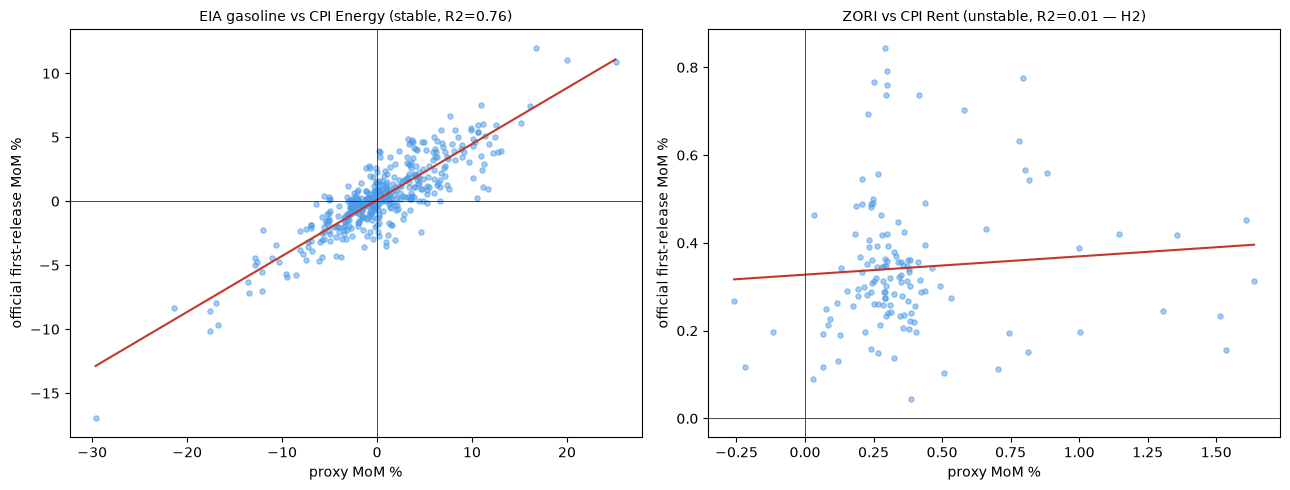

In [2]:
def pair_series(proxy_source, proxy_key, official):
    pm = alignment.monthly_mom(DB, proxy_source, proxy_key)
    ft = dt.datetime.now(ZoneInfo("America/New_York"))
    with open_timebase(DB) as tb:
        om = {}
        for m in sorted(pm):
            try: om[m] = tb.asof_mom_for_ref(official, m, ft)
            except (NoMomExists, NotYetReleased): pass
    common = sorted(set(pm) & set(om))
    return np.array([pm[m] for m in common]), np.array([om[m] for m in common]), common

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
for a, (ps, pk, off, title) in zip(ax, [
    ("eia_gasoline","US","CPIENGSL","EIA gasoline vs CPI Energy (stable, R2=0.76)"),
    ("zori","US","CUSR0000SEHA","ZORI vs CPI Rent (unstable, R2=0.01 — H2)"),
]):
    x, y, _ = pair_series(ps, pk, off)
    a.scatter(x*100, y*100, s=14, alpha=0.5, color="#4c9be8")
    b, r2 = reconcile._ols(x, y)
    xs = np.linspace(x.min(), x.max(), 50)
    a.plot(xs*100, (b*xs + np.mean(y) - b*np.mean(x))*100, color="#c0392b", lw=1.5)
    a.set_xlabel("proxy MoM %"); a.set_ylabel("official first-release MoM %")
    a.set_title(title, fontsize=10); a.axhline(0, lw=.5, c="k"); a.axvline(0, lw=.5, c="k")
plt.tight_layout(); plt.show()

## Rolling 3-year beta stability (why ZORI is flagged UNSTABLE)

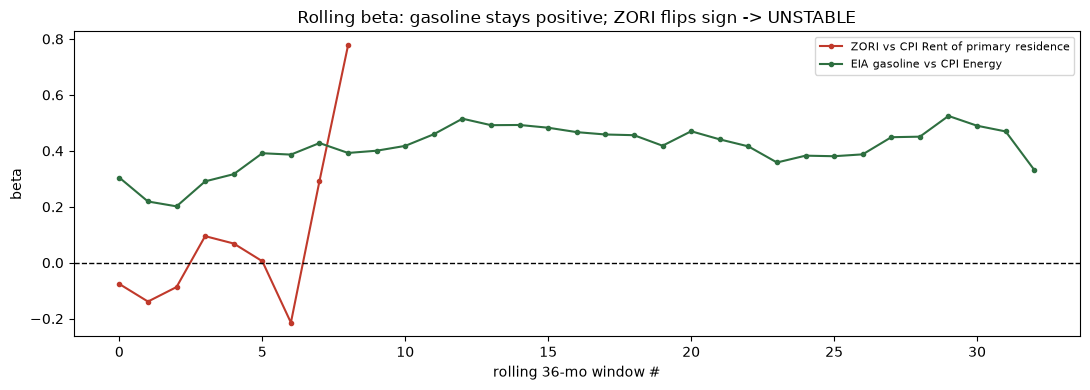

In [3]:
fig, ax = plt.subplots(figsize=(11,4))
for r, color in [(next(r for r in results if r.label.startswith("ZORI vs CPI Rent")), "#c0392b"),
                 (next(r for r in results if r.label.startswith("EIA gasoline")), "#2e6f40")]:
    if r.rolling_betas:
        ax.plot(range(len(r.rolling_betas)), r.rolling_betas, marker="o", ms=3, label=r.label, color=color)
ax.axhline(0, lw=1, c="k", ls="--"); ax.set_xlabel("rolling 36-mo window #"); ax.set_ylabel("beta")
ax.set_title("Rolling beta: gasoline stays positive; ZORI flips sign -> UNSTABLE"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## Reading notes
- **Admit to Session 4:** gasoline (stable, R²=0.76) — but note the pair here is vs the
  Energy aggregate (SETB01 stratum vintages not yet loaded) and NSA-proxy vs SA-official;
  tighten in Session 3A.
- **Do NOT admit as a contemporaneous next-print feature:** ZORI. Its value is as a
  *leading* indicator (H2), a Session-4 lead/lag modelling question — not next-print rent MoM.
- **Monitors** (Atlanta Fed, Indeed): context only, never regressed.
- All ZORI/wage stats are **optimism-flagged** (revised_latest_only): real-time tracking
  was worse than shown here. See docs/reconciliation_report.md.